In [1]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/analysis-tools/4ZGNR


In [2]:
ls

C.psml  H.psml  Untitled.ipynb  zgnr.fdf  zgnrprop.mpr


In [3]:
!siesta < zgnr.fdf > zgnr.out


Job completed


In [4]:
ls

0_NORMAL_EXIT                H.psml               zgnr.DM
BASIS_ENTHALPY               INPUT_TMP.33327      zgnr.EIG
BASIS_HARRIS_ENTHALPY        MESSAGES             zgnr.FA
C.ion                        NON_TRIMMED_KP_LIST  zgnr.fdf
C.ion.nc                     OUTVARS.yml          zgnr.HSX
C.ion.xml                    PARALLEL_DIST        zgnr.KP
CLOCK                        Untitled.ipynb       zgnr.ORB_INDX
C.psml                       zgnr.alloc           zgnr.out
fdf.20260121T102500.743.log  zgnr.bands           zgnrprop.mpr
FORCE_STRESS                 zgnr.BASIS_ENTHALPY  zgnr.STRUCT_OUT
H.ion                        zgnr.bib             zgnr.XV
H.ion.nc                     zgnr.BONDS
H.ion.xml                    zgnr.BONDS_FINAL


## Plotting the DOS

In [5]:
%%bash 

Eig2DOS -f -e -3 -E 3 -s 0.05 -k zgnr.KP zgnr.EIG > dos.dat


In [6]:
%%bash

gnuplot
plot "dos.dat" w l


#### Checking dos.dat is create or any missing file in it.

In [8]:
%%bash

ls -lh dos.dat
head dos.dat
tail dos.dat


-rw-rw-r-- 1 l-rishiraj l-rishiraj 12K Jan 21 10:28 dos.dat
# EIG2DOS: Utility for SIESTA to obtain the electronic density of states
#  E. Artacho, Apr 1999, A. Garcia, Apr 2012
#  Nick R. Papior, Feb 2017
# ------------------------------------------
# Eigenvalues calculated from a spin-polarized calculation
# Eigenvalues read from zgnr.EIG
# Kpoint weights read from zgnr.KP
# Using smearing parameter:   0.0500
# Using 200 points in the energy range
# Selected bands: 1 to: 114
      2.728643      1.634508      1.634079      3.268587
      2.758794      2.296507      2.296731      4.593238
      2.788945      2.474506      2.475343      4.949849
      2.819095      1.740941      1.740579      3.481520
      2.849246      0.879241      0.877686      1.756927
      2.879397      0.613926      0.612840      1.226766
      2.909548      0.541015      0.541585      1.082600
      2.939698      0.312702      0.313682      0.626384
      2.969849      0.202880      0.202668      0.405548
     

#### Create a png file and plot the density of states for both spinup and spin down

In [17]:
%%bash

gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "dos.png"
set xlabel "Energy (eV)"
set ylabel "DOS"
set title "DENSITY OF STATE"
set grid
plot "dos.dat" using 1:2 with lines title "Spin up", \
     "dos.dat" using 1:3 with lines title "Spin down"
EOF


In [18]:
!ls -lh dos.png


-rw-rw-r-- 1 l-rishiraj l-rishiraj 52K Jan 21 10:46 dos.png


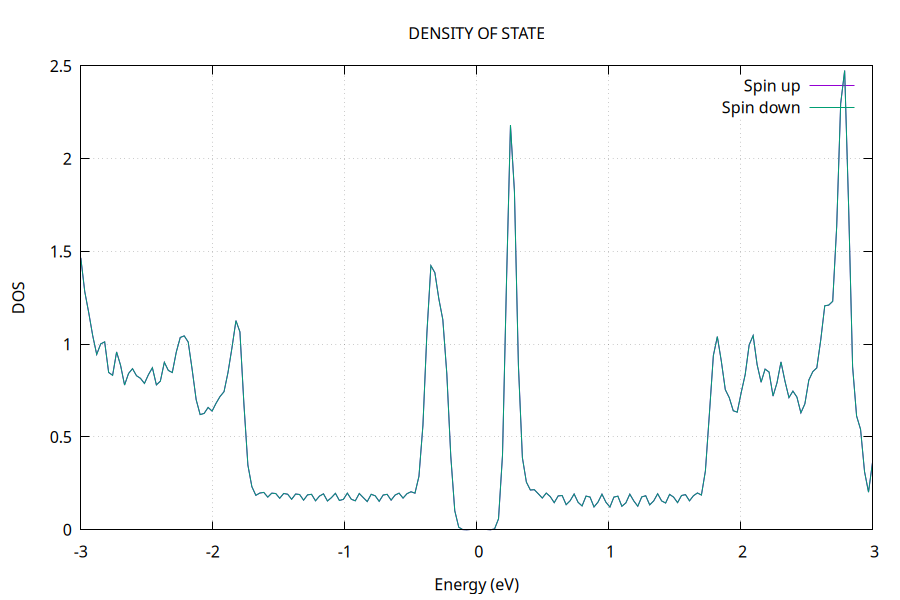

In [19]:
from IPython.display import Image, display
display(Image("dos.png"))


## Ploting the Bandstructure

In [20]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/analysis-tools/4ZGNR


#### create the bands,dat using gnubands

In [25]:
!gnubands -G -F -e -3 -E 3 -o bands zgnr.bands


plot using gnuplot

In [22]:
!gnuplot -persist bands.gplot

In [27]:
ls -lh bands.dat bands.gplot


ls: cannot access 'bands.dat': No such file or directory
-rw-rw-r-- 1 l-rishiraj l-rishiraj 155 Jan 21 10:52 bands.gplot


In [29]:
%%bash

ls -lh zgnr.bands
head -30 zgnr.bands
tail -30 zgnr.bands


-rw-rw-r-- 1 l-rishiraj l-rishiraj 296K Jan 21 10:25 zgnr.bands
  -3.7676396435387631     
   0.0000000000000000       0.66899768137625815     
  -22.593008599643525        154.59537583351647     
         114           2         101
  0.000000    -22.5930    -21.7572    -20.4303    -18.7576    -15.7083    -13.4740    -10.9972    -10.7400     -9.8106     -9.7607
               -9.0846     -8.6880     -8.4149     -8.1190     -7.1733     -7.1303     -6.8304     -0.9593      1.2694      2.0037
                2.1103      3.8051      3.9259      4.2051      4.9975      5.1105      5.6577      6.3719      7.1176      7.6092
                8.0948      9.0815      9.4050      9.5505      9.9030     10.6824     10.9617     11.0691     11.1542     11.1911
               12.0115     12.4785     13.3636     14.2157     15.4993     16.5552     18.3018     18.4331     19.7281     20.2793
               20.7999     21.3252     21.6450     22.5200     23.8076     24.2332     24.4939     24.8710     

In [30]:
!cat bands.gplot


set xtics ("Gamma"  0.000000, "X"  0.668998)
plot "bands" using 1:2:3 with lines lc variable
# -- Use line below for single-color
#plot "bands" with lines


### Create the png file and again display into the python 

In [37]:
%%bash

gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "bands.png"
load "bands.gplot"
EOF


In [38]:
!ls -lh bands.png


-rw-rw-r-- 1 l-rishiraj l-rishiraj 35K Jan 21 10:57 bands.png


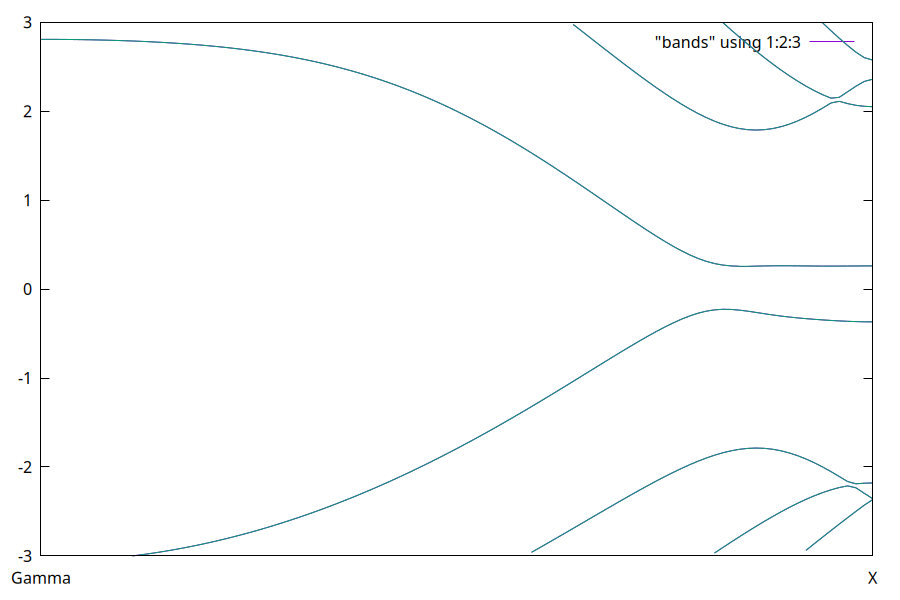

In [39]:
from IPython.display import Image, display
display(Image("bands.png"))


In [40]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/analysis-tools/4ZGNR


In [41]:
!siesta < zgnr.fdf > zgnr.out


Job completed


In [42]:
ls

0_NORMAL_EXIT                FORCE_STRESS         zgnr.bib
bands                        H.ion                zgnr.BONDS
bands.gplot                  H.ion.nc             zgnr.BONDS_FINAL
bands.png                    H.ion.xml            zgnr.DM
BASIS_ENTHALPY               H.psml               zgnr.EIG
BASIS_HARRIS_ENTHALPY        INPUT_TMP.33327      zgnr.FA
C.ion                        INPUT_TMP.89116      zgnr.fdf
C.ion.nc                     MESSAGES             zgnr.fullBZ.WFSX
C.ion.xml                    NON_TRIMMED_KP_LIST  zgnr.HSX
CLOCK                        OUTVARS.yml          zgnr.KP
C.psml                       PARALLEL_DIST        zgnr.ORB_INDX
dos.dat                      Untitled.ipynb       zgnr.out
dos.png                      zgnr.alloc           zgnrprop.mpr
fdf.20260121T102500.743.log  zgnr.bands           zgnr.STRUCT_OUT
fdf.20260121T115556.532.log  zgnr.BASIS_ENTHALPY  zgnr.XV


In [43]:
!ln -sf zgnr.fullBZ.WFSX zgnr.WFSX


In [44]:
%%bash

mprop -n 500 -m -10 -M 3 -s 0.1 zgnrprop


Reading wave-function file (WFSX).
Energy units are eV
Reading wf file: zgnr.fullBZ.WFSX
 NSPIN BLOCKS:            2
Minimum/Maximum number of wfs per k-point:   114  114
Min_eigval, max_eigval on WFS file:     -22.5930    154.5961
Min_eigval, max_eigval in band set :     -22.5930    154.5961
Implicit band set used: (min, max_min, max_max):   1 114 114
Minimum and maximum eigenvalues (based on file data and band selection):     -22.5930    154.5961
* Minimum eigenvalue changed as per user range request:     -10.0000
* Maximum eigenvalue changed as per user range request:       3.0000
Minimum and maximum eigenvalues to be processed:     -10.0000      3.0000
Plotting range adequate for eigenvalue range selected:     -10.3000      3.3000
Using smearing parameter:   0.100
Using    500 points in energy range
 zgnr.HSXNot meaningful to compute Fermi energy, as min_band>1 or restricted eigvals
 Size of set_mask:          114
 Size of set_mask:          114
 Size of set_mask:          114
 Siz

In [46]:
!ls -lh zgnrprop*


-rw-rw-r-- 1 l-rishiraj l-rishiraj  37K Jan 21 11:59 zgnrprop.Cedge1.pdos
-rw-rw-r-- 1 l-rishiraj l-rishiraj  37K Jan 21 11:59 zgnrprop.Cedge2.pdos
-rw-rw-r-- 1 l-rishiraj l-rishiraj   27 Dec 16 11:21 zgnrprop.mpr
-rw-rw-r-- 1 l-rishiraj l-rishiraj 7.7K Jan 21 11:59 zgnrprop.stt


In [48]:
%%bash 

gnuplot << 'EOF'
set terminal pngcairo size 1000,600
set output "pdos_edges.png"
set xlabel "Energy (eV)"
set ylabel "PDOS"
set grid
set key top right

# Spin up = column 2
# Spin down = column 3  (we plot it negative for symmetry)

plot "zgnrprop.Cedge1.pdos" using 1:2 with lines title "Cedge1 up", \
     "zgnrprop.Cedge1.pdos" using 1:(-column(3)) with lines title "Cedge1 down", \
     "zgnrprop.Cedge2.pdos" using 1:2 with lines title "Cedge2 up", \
     "zgnrprop.Cedge2.pdos" using 1:(-column(3)) with lines title "Cedge2 down"
EOF


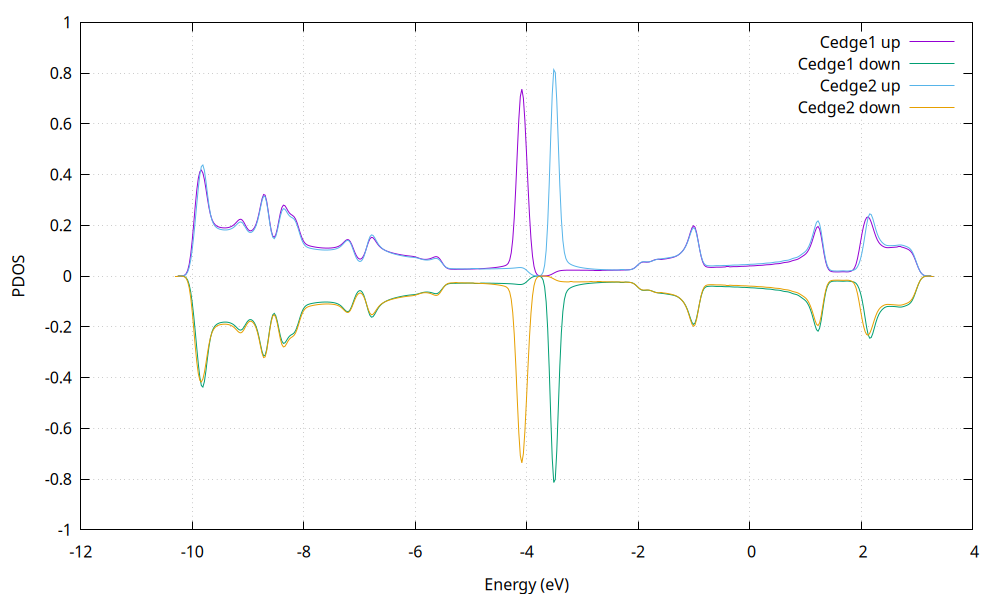

In [49]:
from IPython.display import Image, display
display(Image("pdos_edges.png"))


In [50]:
!ls -lh zgnrprop*.pdos


-rw-rw-r-- 1 l-rishiraj l-rishiraj 37K Jan 21 11:59 zgnrprop.Cedge1.pdos
-rw-rw-r-- 1 l-rishiraj l-rishiraj 37K Jan 21 11:59 zgnrprop.Cedge2.pdos


In [51]:
%%bash

gnuplot << 'EOF'
set terminal pngcairo size 1000,600
set output "pdos_edges.png"
set xlabel "Energy (eV)"
set ylabel "PDOS"
set grid
set key top right

plot "zgnrprop.Cedge1.pdos" u 1:2 w l title "Cedge1 up", \
     "zgnrprop.Cedge1.pdos" u 1:(-column(3)) w l title "Cedge1 down", \
     "zgnrprop.Cedge2.pdos" u 1:2 w l title "Cedge2 up", \
     "zgnrprop.Cedge2.pdos" u 1:(-column(3)) w l title "Cedge2 down"
EOF


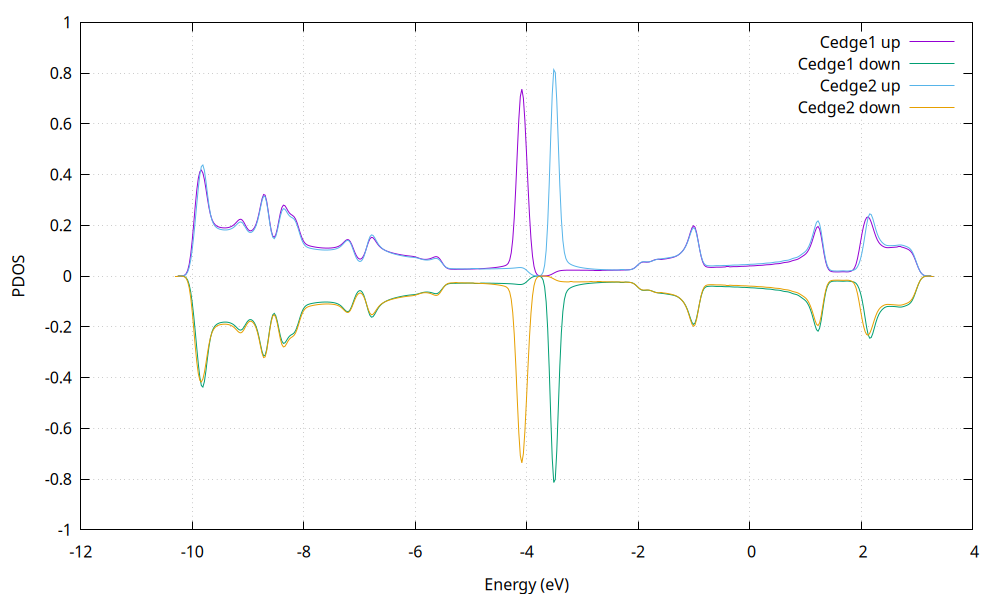

In [52]:
from IPython.display import Image, display
display(Image("pdos_edges.png"))


# Plotting Fat Bands for 4ZGNR

In [54]:
!siesta < zgnr.fdf > zgnr.out

Job completed


In [55]:
!ls -lh zgnr.bands.WFSX


-rw-rw-r-- 1 l-rishiraj l-rishiraj 2.4M Jan 21 12:14 zgnr.bands.WFSX


In [56]:
%%bash

rm -f zgnr.WFSX
ln -sf zgnr.bands.WFSX zgnr.WFSX


In [57]:
!fat zgnrprop


Reading wf file: zgnr.bands.WFSX
 Minimum/Maximum number of wfs per k-point:    13   13
Min_eigval, max_eigval on WFS file:     -11.7677      3.9017
Min_eigval, max_eigval in band set :     -11.7677      3.9017
Band set used: (min, max):   1  13
 zgnr.HSX Size of set_mask:          114
 Size of set_mask:          114
 Size of set_mask:          114
 Size of set_mask:          114
 Total number of curves processed:            2
Writing files: zgnrprop.stt ...
Fatband coeffs set:    Cedge1  Base orbitals and interactions:     13         1605
Fatband coeffs set:    Cedge2  Base orbitals and interactions:     13         1605


In [58]:
!ls -lh *.EIGFAT


-rw-rw-r-- 1 l-rishiraj l-rishiraj 64K Jan 21 12:17 zgnrprop.Cedge1.EIGFAT
-rw-rw-r-- 1 l-rishiraj l-rishiraj 64K Jan 21 12:17 zgnrprop.Cedge2.EIGFAT


In [60]:
%%bash

eigfat2plot zgnrprop.Cedge1.EIGFAT > Cedge1.dat
eigfat2plot zgnrprop.Cedge2.EIGFAT > Cedge2.dat
head Cedge1.dat
head Cedge2.dat



 # # zgnr min_band, max_band:     1   13
 # nband, nspin, nk:          13           2         101
 # min_band, max_band:            1          13
      0.000000     -9.760700      0.060490  1
      0.006690     -9.762700      0.060500  1
      0.013380     -9.768600      0.060510  1
      0.020070     -9.778300      0.060540  1
      0.026760     -9.792000      0.060570  1
      0.033450     -9.797700      0.150440  1
      0.040140     -9.792000      0.150410  1
 # # zgnr min_band, max_band:     1   13
 # nband, nspin, nk:          13           2         101
 # min_band, max_band:            1          13
      0.000000     -9.760700      0.049520  1
      0.006690     -9.762700      0.049530  1
      0.013380     -9.768600      0.049540  1
      0.020070     -9.778300      0.049550  1
      0.026760     -9.792000      0.049580  1
      0.033450     -9.797700      0.120460  1
      0.040140     -9.792000      0.120420  1


In [77]:
%%bash

gnuplot << 'EOF'
set terminal pngcairo size 1000,600
set output "fat_Cedge1_tutorial.png"

set xlabel "k-point index"
set ylabel "Energy (eV)"
set yrange [0:-8]
set grid

# points with size proportional to weight
plot "Cedge1.dat" using 1:2:(3*column(3)) with points pt 6 ps variable notitle, \
     "Cedge1.dat" using 1:2:(3*column(3)) with lines palette lw 6 notitle
EOF


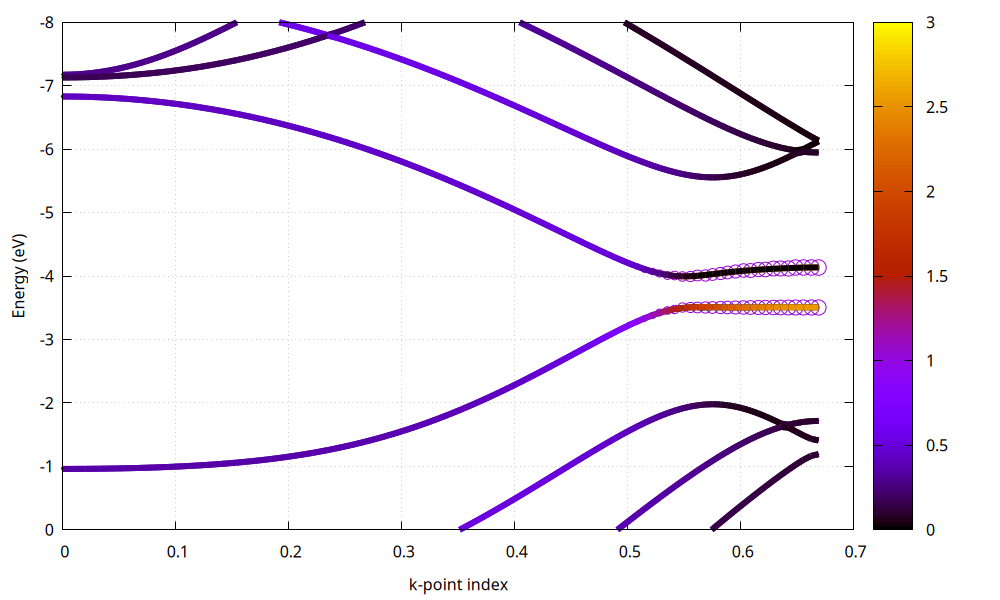

6

In [78]:
from IPython.display import Image, display
display(Image("fat_Cedge1_tutorial.png"))
6


In [71]:
%%bash

gnuplot << 'EOF'
set terminal pngcairo size 1000,600
set output "fat_Cedge1_tutorial_spin.png"

set xlabel "k-point index"
set ylabel "Energy (eV)"
set yrange [0:-8]
set grid

# points with size proportional to weight
plot "Cedge1.dat" using 1:2:(column(3)*(2-column(4))) w p pt 6 ps variable
replot "Cedge1.dat" using 1:2:(column(3)*(column(4)-1)) w p pt 6 ps variable
EOF


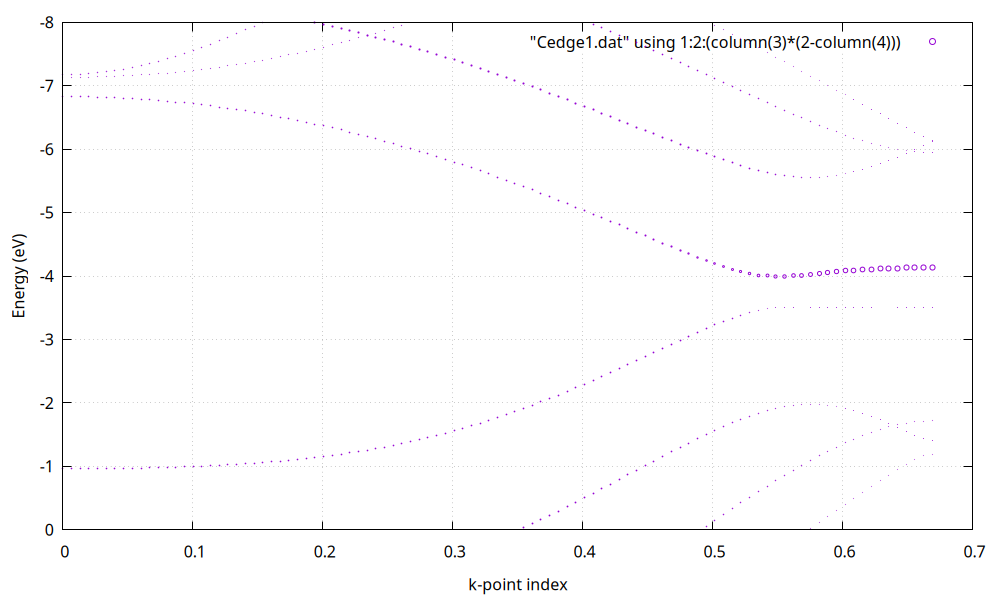

In [72]:
from IPython.display import Image, display
display(Image("fat_Cedge1_tutorial_spin.png"))
